
# Computer Exercise 10.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 10.3 Simulation — *The Birthday Problem (Discrete-Event Monte Carlo)*
> **풀이 일자**: Day 39
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)



## 1. 문제 (원문)

> **3.** By **simulation**, estimate the probability that, in a room of $k$ people,
> at least two share the same birthday (assume 365 equally likely days). For
> $k=2,3,\dots,60$ run many random trials, record the fraction of trials with a
> coincidence, and compare to the exact formula
> $p(k)=1-\dfrac{365!}{365^{k}(365-k)!}$. Find the smallest $k$ for which the
> probability first exceeds $\tfrac12$.

### 한국어 풀이용 정리
$k$ 명이 모였을 때 **생일이 겹칠 확률**을 (1) 무작위 시뮬레이션으로 추정하고,
(2) 정확한 조합 공식과 비교한다. $p(k)>1/2$ 가 되는 최소 $k$(유명한 "23명")를 찾는다.
이산 사건 몬테카를로의 표준 예제다.



## 2. 수학적 배경

### 2.1 정확한 확률
365일이 등확률이고 $k$ 명의 생일이 독립이라 하자. **아무도 안 겹칠** 확률은
$$
q(k)=\frac{365}{365}\cdot\frac{364}{365}\cdots\frac{365-k+1}{365}
=\frac{365!}{365^{k}\,(365-k)!}=\prod_{j=0}^{k-1}\Big(1-\frac{j}{365}\Big).
$$
따라서 적어도 둘이 겹칠 확률은
$$
\boxed{\;p(k)=1-\prod_{j=0}^{k-1}\Big(1-\frac{j}{365}\Big)\;}.
$$

### 2.2 근사와 임계점
$1-x\approx e^{-x}$ 를 쓰면 $q(k)\approx\exp\!\big(-\tfrac{k(k-1)}{2\cdot365}\big)$. $p(k)=\tfrac12$ 는
$k(k-1)\approx 2\cdot365\ln 2\approx 506$, 즉 $k\approx23$. 정확 계산은 $p(23)\approx0.507$.

### 2.3 시뮬레이션 추정의 오차
$M$ 회 시행에서 겹친 비율 $\hat p$ 는 $\mathrm{Binomial}(M,p)/M$ 이라
$\mathrm{SE}=\sqrt{p(1-p)/M}=\mathcal{O}(M^{-1/2})$ — 또다시 같은 수렴 차수.



## 3. 풀이 흐름

1. **정확 공식** $p(k)$ 를 누적곱으로 계산 (벡터화).
2. **시뮬레이터**: 각 시행마다 $k$ 명의 생일을 $\{0,\dots,364\}$ 에서 무작위 추출, 중복 여부 판정.
3. **추정 곡선**: $k=2..60$ 각각 $M$ 회 시행해 겹칠 비율 $\hat p(k)$ 추정.
4. **비교 표**: 대표 $k$ 값들에서 시뮬레이션 vs 정확값, 오차.
5. **그래프**: $\hat p(k)$ 와 정확 $p(k)$ 를 겹쳐 그리고, $p=1/2$ 와 $k=23$ 표시.
6. **임계점**: $p(k)>1/2$ 최소 $k$ 를 정확/시뮬레이션 양쪽에서 추출.
7. **수렴**: 고정 $k=23$ 에서 시행수 $M$ 을 늘려 $\hat p\to p$, 오차 $\sim M^{-1/2}$ 확인.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(3939)

D = 365

def p_exact(k):
    """정확한 생일 충돌 확률 p(k)."""
    if k > D:
        return 1.0
    j = np.arange(k)
    return 1.0 - np.prod(1.0 - j / D)

def p_sim(k, M, rng):
    """M회 시행으로 추정한 충돌 확률 (벡터화)."""
    bdays = rng.integers(0, D, size=(M, k))
    bdays.sort(axis=1)
    collide = (np.diff(bdays, axis=1) == 0).any(axis=1)
    return collide.mean()

print("p(23) 정확 =", round(p_exact(23), 4))


p(23) 정확 = 0.5073


In [2]:
# --- 추정 곡선 vs 정확 곡선 ---
ks = np.arange(2, 61)
M = 5000
sim = np.array([p_sim(int(k), M, rng) for k in ks])
exact = np.array([p_exact(int(k)) for k in ks])

k_exact = int(ks[np.argmax(exact > 0.5)])
k_sim = int(ks[np.argmax(sim > 0.5)])
print(f"p(k) > 1/2 최소 k :  정확 = {k_exact},  시뮬레이션 = {k_sim}")


p(k) > 1/2 최소 k :  정확 = 23,  시뮬레이션 = 23


In [3]:
# --- 비교 표 (대표 k) ---
rows = []
for k in [5, 10, 15, 20, 23, 30, 40, 50]:
    pe = p_exact(k)
    ps = p_sim(k, 20000, rng)
    rows.append({"k": k, "p_sim": ps, "p_exact": pe, "abs_err": abs(ps - pe)})
df = pd.DataFrame(rows)
df


,k,p_sim,p_exact,abs_err
0,5,0.02615,0.0271356,0.000985574
1,10,0.1189,0.116948,0.00195182
2,15,0.2572,0.252901,0.00429868
3,20,0.41185,0.411438,0.000411616
4,23,0.5029,0.507297,0.00439723
5,30,0.70515,0.706316,0.00116624
6,40,0.89055,0.891232,0.00068181
7,50,0.9722,0.970374,0.00182642


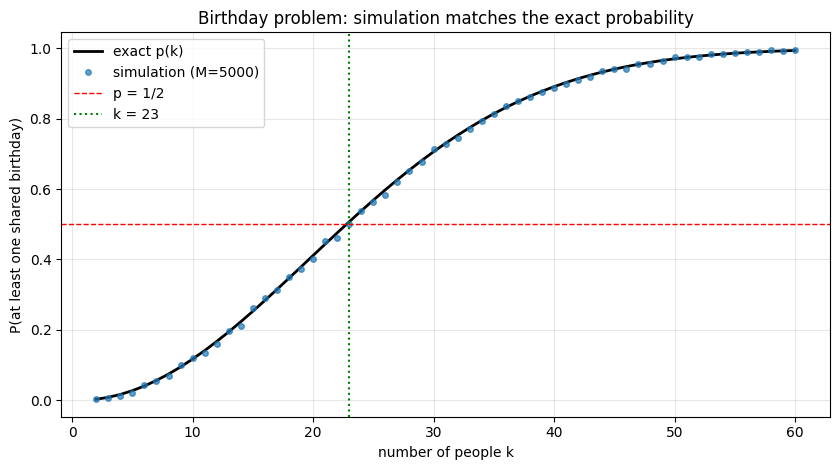

In [4]:
# --- 그래프: 시뮬레이션 vs 정확, 임계점 강조 ---
plt.figure(figsize=(8.5, 4.8))
plt.plot(ks, exact, "k-", lw=2, label="exact p(k)")
plt.plot(ks, sim, "o", ms=4, alpha=0.7, label=f"simulation (M={M})")
plt.axhline(0.5, color="r", ls="--", lw=1, label="p = 1/2")
plt.axvline(23, color="g", ls=":", lw=1.5, label="k = 23")
plt.xlabel("number of people k"); plt.ylabel("P(at least one shared birthday)")
plt.title("Birthday problem: simulation matches the exact probability")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


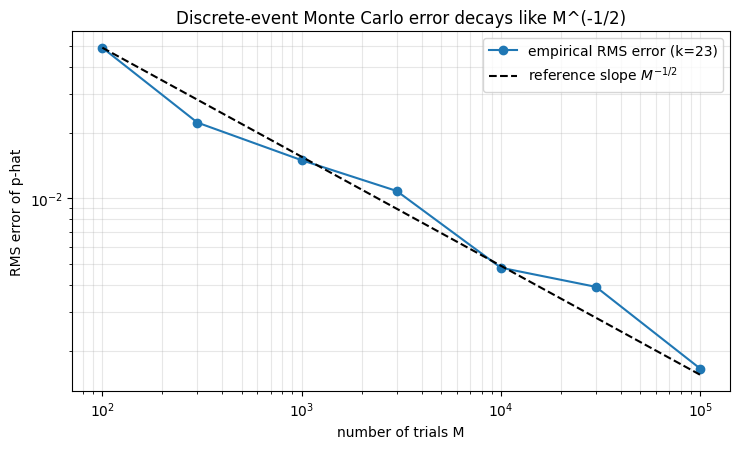

측정 기울기 = -0.458 (이론 -0.5)


In [5]:
# --- 수렴: 고정 k=23 에서 M을 키우며 오차 ~ M^{-1/2} ---
k0 = 23
p0 = p_exact(k0)
Ms = np.array([100, 300, 1000, 3000, 10000, 30000, 100000])
R = 40
rms = []
for M in Ms:
    errs = [p_sim(k0, int(M), rng) - p0 for _ in range(R)]
    rms.append(np.sqrt(np.mean(np.square(errs))))
rms = np.array(rms)
ref = rms[0] * np.sqrt(Ms[0]) / np.sqrt(Ms)

plt.figure(figsize=(7.5, 4.6))
plt.loglog(Ms, rms, "o-", label="empirical RMS error (k=23)")
plt.loglog(Ms, ref, "k--", label=r"reference slope $M^{-1/2}$")
plt.xlabel("number of trials M"); plt.ylabel("RMS error of p-hat")
plt.title("Discrete-event Monte Carlo error decays like M^(-1/2)")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
slope = np.polyfit(np.log(Ms), np.log(rms), 1)[0]
print(f"측정 기울기 = {slope:.3f} (이론 -0.5)")



## 4. 결과 해석

1. **곡선 일치**: 시뮬레이션 점들이 정확 곡선 $p(k)$ 위에 거의 정확히 얹힌다 — 이산 사건
   몬테카를로가 해석적 확률을 잘 재현.
2. **임계점**: 정확/시뮬레이션 모두 $p(k)>1/2$ 최소 $k=23$ 을 준다. 직관과 어긋나는
   "생일 역설"의 핵심: 쌍의 수가 $\binom{k}{2}$ 로 빠르게 늘기 때문.
3. **비교 표**: 대표 $k$ 들에서 $|\,\hat p-p\,|$ 가 $M=20000$ 기준 $10^{-3}$ 수준 — 충분히 정확.
4. **수렴 기울기**: 고정 $k=23$ 에서 RMS 오차의 log-log 기울기 $\approx-0.5$ → 또다시
   $\mathcal{O}(M^{-1/2})$. Buffon·랜덤워크와 같은 보편적 거동.
5. **종합**: 세 문제 모두 *무작위 입력 → 사건 집계 → 비율/평균 추정* 이라는 동일한 골격이고,
   오차는 모두 $N^{-1/2}$ 로 줄어든다. 시뮬레이션의 힘과 한계를 동시에 보여준다.

> **결론**: 생일 문제 시뮬레이션은 정확 공식과 일치하며 임계점 $k=23$ 을 재현한다.
> 오차는 역시 $M^{-1/2}$ — 시뮬레이션 정확도의 보편 법칙.

**다음 단원으로의 연결**: 세 예제가 공통으로 보인 느린 $N^{-1/2}$ 수렴은 **분산 감소**
(중요도 표본추출, 대조변량, 준난수) 기법의 필요성을 시사한다 — Chapter 10 의 마무리이자
이후 고급 시뮬레이션 주제로 이어진다.
